# Macro-activit?s des entreprises ? M?tallurgie



## Objectif et principe

Le fichier source contient deux syst?mes de codification : les codes ant?rieurs ? 2015 sont des **codes risque historiques** et les codes plus r?cents des **codes APE/NAF**. Ils ne sont donc pas ramen?s artificiellement ? une division NAF commune.

Chaque accident re?oit trois variables de tra?abilit? : `company_code`, `company_label` et `coding_system`. Comme ce fichier ne contient pas la date de l'accident, `coding_system` est identifi? par la forme du code : `123AB` est class? `historical_risk_code` et `1234A` est class? `NAF_APE`. La variable `macro_activity` est ensuite construite ? partir du **libell? d'activit?**, au moyen de r?gles explicites et ordonn?es. Elle forme une taxonomie analytique commune aux deux syst?mes, pens?e pour obtenir des contextes professionnels homog?nes et interpr?tables pour la d?couverte locale de motifs.

Les familles comptant au moins `MIN_CANDIDATE_SIZE` accidents sont des candidates ? l'analyse locale. Les autres sont conserv?es dans `macro_activity_raw`, mais leur `macro_activity` est fix?e ? `Other activities`. Chaque ligne export?e conserve `accident_id`, le code, le libell?, le syst?me, la r?gle appliqu?e et la famille finale.


In [1]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

DATASET = "metallurgie"
DATA_PATH = Path("data/metallurgie_sentence_accidents.csv")
EXPORT_PATH = Path("../dataset/company_family_metallurgie.csv")
MIN_CANDIDATE_SIZE = 50
TAXONOMY_VERSION = "label_based_macro_activity_v1"


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

sentences = pd.read_csv(DATA_PATH, dtype={"accident_id": "string", "company_code": "string"})
required_columns = {"accident_id", "company_code"}
missing_columns = required_columns.difference(sentences.columns)
if missing_columns:
    raise ValueError(f"Colonnes absentes : {sorted(missing_columns)}")

company_values = sentences.assign(company_code=sentences["company_code"].astype("string").str.strip())
company_values["company_code"] = company_values["company_code"].replace("", pd.NA)
conflicts = company_values.groupby("accident_id", dropna=False)["company_code"].nunique(dropna=True)
if conflicts.gt(1).any():
    raise ValueError("Au moins un accident poss?de plusieurs codes entreprise distincts.")

accidents = (
    company_values.groupby("accident_id", as_index=False, dropna=False)["company_code"]
    .agg(lambda values: values.dropna().iloc[0] if not values.dropna().empty else pd.NA)
    .rename(columns={"company_code": "company_code_raw"})
)
print(f"{DATASET}: {len(accidents):,} accidents uniques")


metallurgie: 3,212 accidents uniques


In [3]:
TAXONOMY_RULES = (
    ("automotive_repair_and_trade", "Automotive repair and trade", r"d.pannage|remorquage|r.par.*v.hicul|entretien.*v.hicul|commerce.*v.hicul|importations.*automobil|vente.*r.par|.lectricit.*automobil"),
    ("automotive_manufacturing", "Automotive manufacturing", r"voitures|v.hicules.*(utilitaires|blind)|.quipements.*automobil|pi.ces.*automobil|carrosser|bennes|remorques|motocycles|cycles"),
    ("transport_equipment_manufacturing", "Transport equipment manufacturing", r"navires|a.ronefs|a.rospat|ferroviaire|voies ferr.es|locomotives"),
    ("machinery_and_equipment_manufacturing", "Machinery and equipment manufacturing", r"machines|ascenseurs|monte.charges|mat.riel agricole|moteurs|pompes|compresseurs|turbines|levage|manutention|outillage|matrices|poin.ons|moules|fours|br.leurs|transmissions|robinetterie"),
    ("electrical_and_electronic_equipment", "Electrical and electronic equipment", r".lectriq|.lectron|t.l.phon|c.bles|automatis|appareils.*(mesure|contr.le|r.gulation)|optique|informatique|.clairage"),
    ("industrial_maintenance_and_installation", "Industrial maintenance and intervention", r"intervention|montage|d.montage|r.par|entretien|reconstruction|installation"),
    ("metal_construction", "Metal construction", r"construction m.tall|charpente|menuiseries m.tall|structures m.tall|serrurerie|tuyauterie"),
    ("metal_forming_and_fabrication", "Metal forming and fabrication", r"d.coupage|emboutissage|chaudronnerie|forge|estampage|usinage|m.canique industrielle|d.colletage|traitement.*m.taux|rev.tement.*m.taux|articles m.tall|quincaillerie|boulonnerie|visserie|ressorts|soudure|conditionnement m.tall|ferblanterie|emballage m.tall|m.tallurgie des poudres"),
    ("primary_metal_and_foundry", "Foundry and primary metal processing", r"sid.rurgie|fonte|acier|laminage|fonderie|tr.filage|profilage|m.taux non|aluminium|cuivre|plomb|zinc|tain|m.tallurgie"),
)


parsed = accidents["company_code_raw"].astype("string").str.extract(
    r"^\s*(?P<company_code>(?:\d{4}[A-Z]|\d{3}[A-Z]{2}))\s*-\s*(?P<company_label>.+?)\s*$"
)
accidents["company_code"] = parsed["company_code"].astype("string")
accidents["company_label"] = parsed["company_label"].astype("string")

# La forme du code distingue les syst?mes, sans supposer de correspondance entre eux.
accidents["coding_system"] = pd.Series("unclassified", index=accidents.index, dtype="string")
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{3}[A-Z]{2}").fillna(False), "coding_system"] = "historical_risk_code"
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{4}[A-Z]").fillna(False), "coding_system"] = "NAF_APE"


def assign_macro_activity(label: object) -> tuple[str, str]:
    if pd.isna(label):
        return "Other activities", "missing_or_unparseable_label"
    label_text = str(label).lower()
    for rule_id, macro_activity, pattern in TAXONOMY_RULES:
        if re.search(pattern, label_text):
            return macro_activity, rule_id
    return "Other activities", "no_taxonomy_rule_matched"

assignments = accidents["company_label"].map(assign_macro_activity)
accidents[["macro_activity_raw", "macro_activity_rule"]] = pd.DataFrame(
    assignments.tolist(), index=accidents.index
)
accidents["macro_activity_raw"] = accidents["macro_activity_raw"].astype("string")
accidents["macro_activity_rule"] = accidents["macro_activity_rule"].astype("string")

raw_counts = accidents["macro_activity_raw"].value_counts()
accidents["macro_activity_size_before_other"] = accidents["macro_activity_raw"].map(raw_counts).astype("Int64")
accidents["macro_activity"] = accidents["macro_activity_raw"].copy()
small_or_other = (
    accidents["macro_activity_raw"].eq("Other activities")
    | accidents["macro_activity_size_before_other"].lt(MIN_CANDIDATE_SIZE)
)
accidents.loc[small_or_other, "macro_activity"] = "Other activities"
accidents["is_local_analysis_candidate"] = ~accidents["macro_activity"].eq("Other activities")
accidents["family"] = accidents["macro_activity"]
accidents["family_grouping_reason"] = pd.Series(
    "Rule applied to company_label: " + accidents["macro_activity_rule"],
    index=accidents.index,
    dtype="string",
)
accidents.loc[small_or_other, "family_grouping_reason"] = (
    "Other activities: raw macro-activity is unmatched or below "
    + str(MIN_CANDIDATE_SIZE)
    + " accidents; raw assignment retained in macro_activity_raw."
)
accidents["taxonomy_version"] = TAXONOMY_VERSION


In [4]:
def distribution(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    table = frame[column].fillna("Not recorded").value_counts(dropna=False).rename_axis(column).reset_index(name="n_accidents")
    table["part_pct"] = (100 * table["n_accidents"] / len(frame)).round(1)
    return table

summary = pd.DataFrame([{
    "dataset": DATASET,
    "n_accidents": len(accidents),
    "n_historical_risk_code": int(accidents["coding_system"].eq("historical_risk_code").sum()),
    "n_NAF_APE": int(accidents["coding_system"].eq("NAF_APE").sum()),
    "n_local_analysis_candidates": int(accidents["is_local_analysis_candidate"].sum()),
    "n_candidate_macro_activities": int(accidents.loc[accidents["is_local_analysis_candidate"], "macro_activity"].nunique()),
    "minimum_candidate_size": MIN_CANDIDATE_SIZE,
}])
macro_distribution = distribution(accidents, "macro_activity")
raw_macro_distribution = distribution(accidents, "macro_activity_raw")
coding_system_distribution = distribution(accidents, "coding_system")
rule_audit = (
    accidents.groupby(["macro_activity_rule", "macro_activity_raw"], dropna=False)
    .agg(n_accidents=("accident_id", "size"), n_company_codes=("company_code", "nunique"))
    .reset_index()
    .sort_values("n_accidents", ascending=False, kind="stable")
)

print("Summary")
display(summary)
print("Macro-activity distribution")
display(macro_distribution)
print("Mapping-rule audit")
display(rule_audit)


Summary


,dataset,n_accidents,n_historical_risk_code,n_NAF_APE,n_local_analysis_candidates,n_candidate_macro_activities,minimum_candidate_size
0,metallurgie,3212,2729,483,2893,9,50


Macro-activity distribution


,macro_activity,n_accidents,part_pct
0,Metal forming and fabrication,691,21.5
1,Machinery and equipment manufacturing,470,14.6
2,Foundry and primary metal processing,362,11.3
3,Automotive repair and trade,343,10.7
4,Automotive manufacturing,320,10.0
5,Other activities,319,9.9
6,Industrial maintenance and intervention,284,8.8
7,Electrical and electronic equipment,264,8.2
8,Metal construction,80,2.5
9,Transport equipment manufacturing,79,2.5


Mapping-rule audit


,macro_activity_rule,macro_activity_raw,n_accidents,n_company_codes
6,metal_forming_and_fabrication,Metal forming and fabrication,691,24
4,machinery_and_equipment_manufacturing,Machinery and equipment manufacturing,470,38
8,primary_metal_and_foundry,Foundry and primary metal processing,362,21
1,automotive_repair_and_trade,Automotive repair and trade,343,9
0,automotive_manufacturing,Automotive manufacturing,320,10
7,no_taxonomy_rule_matched,Other activities,319,66
3,industrial_maintenance_and_installation,Industrial maintenance and intervention,284,15
2,electrical_and_electronic_equipment,Electrical and electronic equipment,264,29
5,metal_construction,Metal construction,80,4
9,transport_equipment_manufacturing,Transport equipment manufacturing,79,8


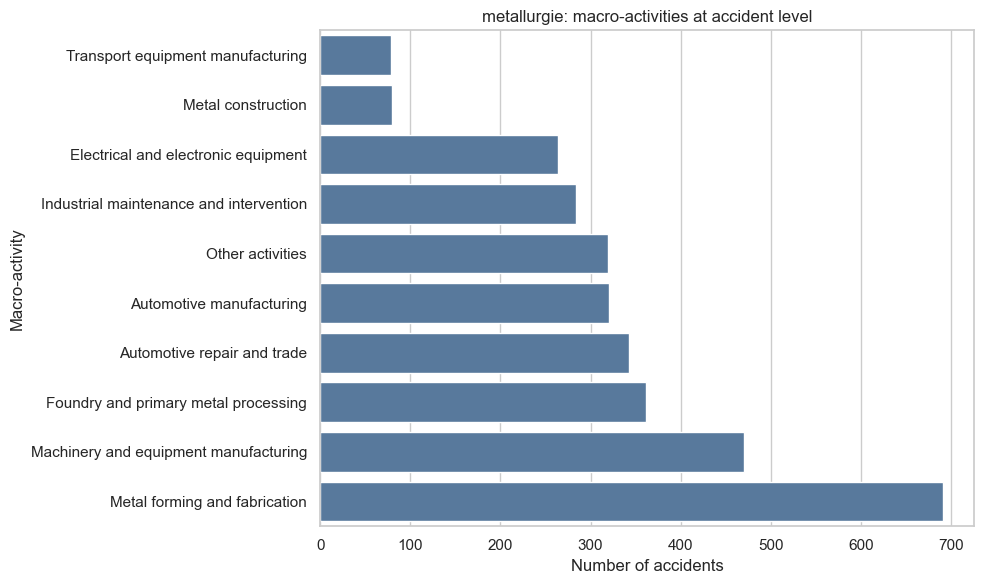

In [5]:
sns.set_theme(style="whitegrid")
plot_data = macro_distribution.sort_values("n_accidents", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, y="macro_activity", x="n_accidents", color="#4C78A8", ax=ax)
ax.set_title(f"{DATASET}: macro-activities at accident level")
ax.set_xlabel("Number of accidents")
ax.set_ylabel("Macro-activity")
plt.tight_layout()
plt.show()


## Audit de la taxonomie

Les r?gles de la cellule de classification sont volontairement visibles et appliqu?es dans l'ordre indiqu?. Le tableau `rule_audit` donne leur effectif. Les lignes sans r?gle, ainsi que les familles sous le seuil, restent dans `Other activities`; leur affectation initiale demeure disponible dans `macro_activity_raw` pour contr?le expert et r?vision de la taxonomie.


In [6]:
export_columns = [
    "accident_id",
    "company_code_raw",
    "company_code",
    "company_label",
    "coding_system",
    "macro_activity_raw",
    "macro_activity_rule",
    "macro_activity_size_before_other",
    "macro_activity",
    "is_local_analysis_candidate",
    "family",
    "family_grouping_reason",
    "taxonomy_version",
]
family_export = accidents[export_columns].sort_values("accident_id", kind="stable")
if not family_export["accident_id"].is_unique:
    raise AssertionError("The export must contain one row per accident_id.")
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
family_export.to_csv(EXPORT_PATH, index=False)
print(f"Export written: {EXPORT_PATH.resolve()}")
display(family_export.head())

# Example join:
# dataset = pd.read_csv(Path(f"../dataset/data_{DATASET}.csv"), dtype={"accident_id": "string"})
# dataset_with_family = dataset.merge(family_export[["accident_id", "family"]], on="accident_id", how="left")


Export written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\company_family_metallurgie.csv


,accident_id,company_code_raw,company_code,company_label,coding_system,macro_activity_raw,macro_activity_rule,macro_activity_size_before_other,macro_activity,is_local_analysis_candidate,family,family_grouping_reason,taxonomy_version
0,000D84B1F9D28BF4C125719D005193F7,287LE - Fabrication d'articles métalliques divers et ferblanterie. Repoussage des métaux en feuilles,287LE,Fabrication d'articles métalliques divers et ferblanterie. Repoussage des métaux en feuilles,historical_risk_code,Metal forming and fabrication,metal_forming_and_fabrication,691,Metal forming and fabrication,True,Metal forming and fabrication,Rule applied to company_label: metal_forming_and_fabrication,label_based_macro_activity_v1
1,0017468054888DC0C125719D005572CD,285AA - Traitement et revêtement des métaux,285AA,Traitement et revêtement des métaux,historical_risk_code,Metal forming and fabrication,metal_forming_and_fabrication,691,Metal forming and fabrication,True,Metal forming and fabrication,Rule applied to company_label: metal_forming_and_fabrication,label_based_macro_activity_v1
2,00191D8E37D5D3AFC125719D0050EF02,"295JB - Fabrication de machines et matériels pour les industries textiles, du cuir, de la chaussure, du papier-carton",295JB,"Fabrication de machines et matériels pour les industries textiles, du cuir, de la chaussure, du papier-carton",historical_risk_code,Machinery and equipment manufacturing,machinery_and_equipment_manufacturing,470,Machinery and equipment manufacturing,True,Machinery and equipment manufacturing,Rule applied to company_label: machinery_and_equipment_manufacturing,label_based_macro_activity_v1
3,001C521AF6A9CD1CC125719D0055BEF1,292FH - Fabrication et installation associées de matériels industriels aérauliques ou frigorifiques,292FH,Fabrication et installation associées de matériels industriels aérauliques ou frigorifiques,historical_risk_code,Industrial maintenance and intervention,industrial_maintenance_and_installation,284,Industrial maintenance and intervention,True,Industrial maintenance and intervention,Rule applied to company_label: industrial_maintenance_and_installation,label_based_macro_activity_v1
4,001ED9E54DAF8A72C1257D1700269769,"285DG - Travaux d'intervention, de montage, démontage et entretien de matériels divers dans les usines. Réparateurs mécaniciens. Fabrication de manèges pour fêtes foraines",285DG,"Travaux d'intervention, de montage, démontage et entretien de matériels divers dans les usines. Réparateurs mécaniciens. Fabrication de manèges pour fêtes foraines",historical_risk_code,Industrial maintenance and intervention,industrial_maintenance_and_installation,284,Industrial maintenance and intervention,True,Industrial maintenance and intervention,Rule applied to company_label: industrial_maintenance_and_installation,label_based_macro_activity_v1


## Export des sous-corpus pour le topic modeling

Cette cellule cr?e un couple unit?s?embeddings par macro-activit? candidate. Les vecteurs existants sont filtr?s par `fact_id`/`doc_id` ; aucun r?-encodage n?est effectu?.


In [7]:
# Build topic-modeling inputs for selected macro-activity families.
# The generated unit and embedding files remain aligned through fact_id / doc_id.
# Re-run this cell after changing the taxonomy or the threshold above.

FAMILIES_TO_EXPORT = None  # None = all local-analysis candidates; or e.g. ["Metal forming and fabrication"]
INCLUDE_OTHER_ACTIVITIES = False
SOURCE_UNITS_PATH = Path(f"../dataset/data_{DATASET}.csv")
SOURCE_EMBEDDINGS_PATH = Path(f"../embeddings/Qwen3-Embedding-0.6B_{DATASET}.csv")
FAMILY_DATASET_DIR = Path(f"../dataset/families/{DATASET}")
FAMILY_EMBEDDING_DIR = Path(f"../embeddings/families/{DATASET}")

if not SOURCE_UNITS_PATH.is_file() or not SOURCE_EMBEDDINGS_PATH.is_file():
    raise FileNotFoundError("Source units or embeddings file is missing.")


def is_true(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y", "t"})


def corpus_slug(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


selected_families = sorted(
    family_export.loc[family_export["is_local_analysis_candidate"], "macro_activity"].dropna().unique().tolist()
)
if INCLUDE_OTHER_ACTIVITIES:
    selected_families.append("Other activities")
if FAMILIES_TO_EXPORT is not None:
    requested = set(FAMILIES_TO_EXPORT)
    unknown = requested.difference(selected_families)
    if unknown:
        raise ValueError(f"Unknown or ineligible families: {sorted(unknown)}")
    selected_families = [family for family in selected_families if family in requested]
if not selected_families:
    raise ValueError("No family selected for export.")

units_source = pd.read_csv(SOURCE_UNITS_PATH, dtype={"accident_id": "string", "fact_id": "string"})
required_unit_columns = {"accident_id", "fact_id", "sentence", "pred_label"}
missing_unit_columns = required_unit_columns.difference(units_source.columns)
if missing_unit_columns:
    raise ValueError(f"Missing unit columns: {sorted(missing_unit_columns)}")

family_lookup = family_export[["accident_id", "macro_activity", "family", "is_local_analysis_candidate"]].copy()
family_lookup["accident_id"] = family_lookup["accident_id"].astype("string")
units_source["accident_id"] = units_source["accident_id"].astype("string")
units_source["fact_id"] = units_source["fact_id"].astype("string")
units_with_family = units_source.merge(family_lookup, on="accident_id", how="inner", validate="many_to_one")

# Match the exact filtering performed by recurrent_scenarios.load_units.
ready_mask = units_with_family["sentence"].fillna("").astype(str).str.strip().ne("")
ready_mask &= units_with_family["pred_label"].astype(str).str.strip().isin({"A0", "A1", "B", "C"})
if "pred_ok" in units_with_family.columns:
    ready_mask &= is_true(units_with_family["pred_ok"])
topic_ready_units = units_with_family.loc[ready_mask].copy()
if topic_ready_units["fact_id"].duplicated().any():
    raise ValueError("fact_id must be unique after topic-input filtering.")

embeddings_source = pd.read_csv(SOURCE_EMBEDDINGS_PATH, dtype={"doc_id": "string"})
if "doc_id" not in embeddings_source.columns:
    raise ValueError("Embeddings must contain doc_id.")
if embeddings_source["doc_id"].duplicated().any():
    raise ValueError("Embedding doc_id must be unique.")

FAMILY_DATASET_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
manifest_rows = []
for family in selected_families:
    corpus_id = f"{DATASET}_{corpus_slug(family)}"
    family_units = topic_ready_units.loc[topic_ready_units["macro_activity"].eq(family)].copy()
    fact_ids = family_units["fact_id"].astype("string")
    family_embeddings = embeddings_source.loc[embeddings_source["doc_id"].isin(fact_ids)].copy()

    missing_embeddings = set(fact_ids).difference(set(family_embeddings["doc_id"]))
    if missing_embeddings:
        raise ValueError(f"{corpus_id}: {len(missing_embeddings)} units have no embedding.")
    if len(family_embeddings) != len(family_units):
        raise ValueError(f"{corpus_id}: units / embeddings row count mismatch.")

    units_path = FAMILY_DATASET_DIR / f"data_{corpus_id}.csv"
    embeddings_path = FAMILY_EMBEDDING_DIR / f"Qwen3-Embedding-0.6B_{corpus_id}.csv"
    family_units.to_csv(units_path, index=False)
    family_embeddings.to_csv(embeddings_path, index=False)
    manifest_rows.append({
        "dataset_id": corpus_id,
        "macro_activity": family,
        "n_accidents": int(family_units["accident_id"].nunique()),
        "n_units": int(len(family_units)),
        "n_embeddings": int(len(family_embeddings)),
        "units_path": str(units_path),
        "embeddings_path": str(embeddings_path),
    })

family_topic_manifest = pd.DataFrame(manifest_rows).sort_values("dataset_id", kind="stable")
manifest_path = FAMILY_DATASET_DIR / "topic_modeling_manifest.csv"
family_topic_manifest.to_csv(manifest_path, index=False)
display(family_topic_manifest)
print(f"Manifest written: {manifest_path.resolve()}")
print("Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh")


,dataset_id,macro_activity,n_accidents,n_units,n_embeddings,units_path,embeddings_path
0,metallurgie_automotive_manufacturing,Automotive manufacturing,320,2314,2314,..\dataset\families\metallurgie\data_metallurgie_automotive_manufacturing.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_automotive_manufacturing.csv
1,metallurgie_automotive_repair_and_trade,Automotive repair and trade,343,2106,2106,..\dataset\families\metallurgie\data_metallurgie_automotive_repair_and_trade.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_automotive_repair_and_trade.csv
2,metallurgie_electrical_and_electronic_equipment,Electrical and electronic equipment,264,1484,1484,..\dataset\families\metallurgie\data_metallurgie_electrical_and_electronic_equipment.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_electrical_and_electronic_equipment.csv
3,metallurgie_foundry_and_primary_metal_processing,Foundry and primary metal processing,362,2656,2656,..\dataset\families\metallurgie\data_metallurgie_foundry_and_primary_metal_processing.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_foundry_and_primary_metal_processing.csv
4,metallurgie_industrial_maintenance_and_intervention,Industrial maintenance and intervention,284,2011,2011,..\dataset\families\metallurgie\data_metallurgie_industrial_maintenance_and_intervention.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_industrial_maintenance_and_intervention.csv
5,metallurgie_machinery_and_equipment_manufacturing,Machinery and equipment manufacturing,470,3187,3187,..\dataset\families\metallurgie\data_metallurgie_machinery_and_equipment_manufacturing.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_machinery_and_equipment_manufacturing.csv
6,metallurgie_metal_construction,Metal construction,80,669,669,..\dataset\families\metallurgie\data_metallurgie_metal_construction.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_metal_construction.csv
7,metallurgie_metal_forming_and_fabrication,Metal forming and fabrication,691,4797,4797,..\dataset\families\metallurgie\data_metallurgie_metal_forming_and_fabrication.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_metal_forming_and_fabrication.csv
8,metallurgie_transport_equipment_manufacturing,Transport equipment manufacturing,79,587,587,..\dataset\families\metallurgie\data_metallurgie_transport_equipment_manufacturing.csv,..\embeddings\families\metallurgie\Qwen3-Embedding-0.6B_metallurgie_transport_equipment_manufacturing.csv


Manifest written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\families\metallurgie\topic_modeling_manifest.csv
Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh
